In [1]:
import pandas as pd
import numpy as np 

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df_long = pd.read_csv("UGov_Data_Long.csv", low_memory=False)

print("Original shape:", df_long.shape)

Original shape: (753662, 18)


# Predictive Modelling

Logistic Regression (Baseline Model)

In [4]:
# 1. Create binary outcome
df_long["adherent"] = (df_long["adherence_score"] >= 4).astype(int)

# 2. Check the outcome
print(df_long["adherent"].value_counts())
print(df_long["adherent"].mean())

# 3. Make sure cost_group is categorical with low as reference
df_long["cost_group"] = pd.Categorical(
    df_long["cost_group"],
    categories=["low", "medium", "high"],
    ordered=True
)

print(df_long[["cost_group", "adherent"]].head())

adherent
1    491289
0    262373
Name: count, dtype: int64
0.6518691402777372
  cost_group  adherent
0     medium         0
1     medium         0
2     medium         1
3     medium         1
4     medium         0


In [5]:
import statsmodels.formula.api as smf
import numpy as np

# Keep only columns needed for the first simple model
model_data = df_long[[
    "adherent",
    "cost_group",
    "age_group",
    "gender",
    "survey_week",
]].dropna().copy()

# Make sure cost_group has low as the reference
model_data["cost_group"] = pd.Categorical(
    model_data["cost_group"],
    categories=["low", "medium", "high"],
    ordered=True
)

# Make sure gender is categorical
model_data["gender"] = model_data["gender"].astype("category")

# Fit simple logistic regression
logit_model = smf.logit(
    formula="adherent ~ C(cost_group, Treatment(reference='low')) + age_group + C(gender) + survey_week",
    data=model_data
).fit()

# Print summary
print(logit_model.summary())

# Odds ratios
odds_ratios = pd.DataFrame({
    "Variable": logit_model.params.index,
    "Coefficient": logit_model.params.values,
    "Odds Ratio": np.exp(logit_model.params.values),
    "P-value": logit_model.pvalues.values
})

print("\nODDS RATIOS:")
print(odds_ratios)

Optimization terminated successfully.
         Current function value: 0.596632
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               adherent   No. Observations:               753662
Model:                          Logit   Df Residuals:                   753604
Method:                           MLE   Df Model:                           57
Date:                Mon, 27 Apr 2026   Pseudo R-squ.:                 0.07682
Time:                        11:36:34   Log-Likelihood:            -4.4966e+05
converged:                       True   LL-Null:                   -4.8708e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------
Intercept                 

In [6]:
# Keep only the most important results
main_results = odds_ratios[
    odds_ratios["Variable"].str.contains("cost_group|gender|age_group", regex=True)
].copy()

print(main_results)

                                             Variable  Coefficient  \
1   C(cost_group, Treatment(reference='low'))[T.me...    -1.204027   
2   C(cost_group, Treatment(reference='low'))[T.high]    -1.691354   
3                                   C(gender)[T.Male]    -0.146202   
57                                          age_group     0.001066   

    Odds Ratio        P-value  
1     0.299984   0.000000e+00  
2     0.184270   0.000000e+00  
3     0.863984  1.917664e-181  
57    1.001067   9.057452e-13  


In [8]:
df_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753662 entries, 0 to 753661
Data columns (total 19 columns):
 #   Column                                      Non-Null Count   Dtype   
---  ------                                      --------------   -----   
 0   record_id                                   753662 non-null  int64   
 1   response_time                               753662 non-null  object  
 2   survey_week                                 753662 non-null  object  
 3   age_group                                   753662 non-null  int64   
 4   gender                                      753662 non-null  object  
 5   state                                       753662 non-null  object  
 6   household_size                              753662 non-null  int64   
 7   employment_status                           753662 non-null  object  
 8   survey_weight                               753662 non-null  float64 
 9   would_self_isolate_if_symptomatic           753662 non-null

In [7]:
# Create a small prediction dataset
pred_data = pd.DataFrame({
    "cost_group": ["low", "medium", "high"],
    "age_group": [model_data["age_group"].median()] * 3,
    "gender": [model_data["gender"].mode()[0]] * 3,
    "survey_week": [model_data["survey_week"].mode()[0]] * 3
})

# Match categories exactly to the model data
pred_data["cost_group"] = pd.Categorical(
    pred_data["cost_group"],
    categories=model_data["cost_group"].cat.categories,
    ordered=True
)

pred_data["gender"] = pd.Categorical(
    pred_data["gender"],
    categories=model_data["gender"].cat.categories
)

pred_data["survey_week"] = pd.Categorical(
    pred_data["survey_week"],
    categories=model_data["survey_week"].cat.categories
)

# Predict probabilities
pred_data["predicted_probability"] = logit_model.predict(pred_data)

print(pred_data)

AttributeError: Can only use .cat accessor with a 'category' dtype

In [ ]:
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

# Cost-only logistic regression
model_cost_only = smf.logit(
    formula="adherent ~ C(cost_group, Treatment(reference='low'))",
    data=df_long
).fit()

print(model_cost_only.summary())

# Odds ratios for the cost-only model
odds_cost_only = pd.DataFrame({
    "Variable": model_cost_only.params.index,
    "Coefficient": model_cost_only.params.values,
    "Odds Ratio": np.exp(model_cost_only.params.values),
    "P-value": model_cost_only.pvalues.values
})

print("\nCOST-ONLY MODEL ODDS RATIOS:")
print(odds_cost_only)

Optimization terminated successfully.
         Current function value: 0.611701
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               adherent   No. Observations:               753662
Model:                          Logit   Df Residuals:                   753659
Method:                           MLE   Df Model:                            2
Date:                Sun, 26 Apr 2026   Pseudo R-squ.:                 0.05351
Time:                        09:58:04   Log-Likelihood:            -4.6102e+05
converged:                       True   LL-Null:                   -4.8708e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------
Intercept                 

In [ ]:
# Compare cost-group odds ratios from both models
compare_models = pd.DataFrame({
    "Model": ["Cost only", "Cost only", "Adjusted", "Adjusted"],
    "Predictor": ["Medium vs Low", "High vs Low", "Medium vs Low", "High vs Low"],
    "Odds Ratio": [
        odds_cost_only.loc[1, "Odds Ratio"],
        odds_cost_only.loc[2, "Odds Ratio"],
        odds_ratios.loc[1, "Odds Ratio"],
        odds_ratios.loc[2, "Odds Ratio"]
    ]
})

print(compare_models)

       Model      Predictor  Odds Ratio
0  Cost only  Medium vs Low    0.308659
1  Cost only    High vs Low    0.192701
2   Adjusted  Medium vs Low    0.299984
3   Adjusted    High vs Low    0.184270


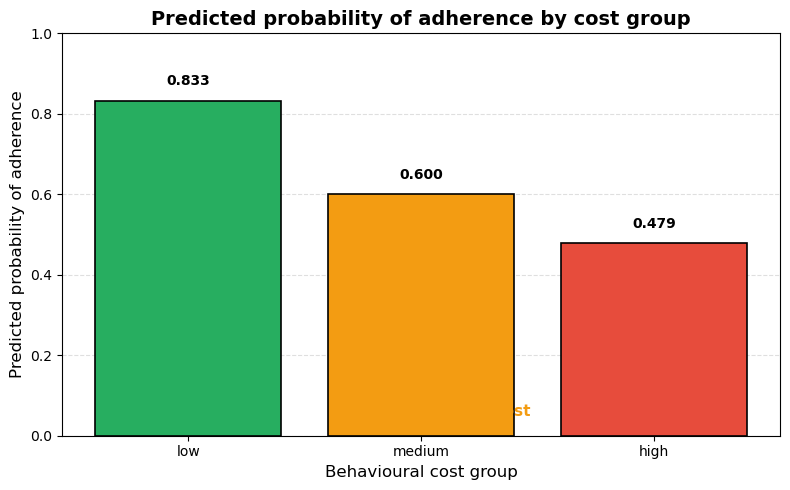

In [ ]:
import matplotlib.pyplot as plt

# Plot predicted probabilities by cost group
fig, ax = plt.subplots(figsize=(8, 5))

colors = ["#27ae60", "#f39c12", "#e74c3c"]  # Low, Medium, High cost
bars = ax.bar(pred_data["cost_group"], pred_data["predicted_probability"], color=colors, edgecolor="black", linewidth=1.2)

ax.set_title("Predicted probability of adherence by cost group", fontsize=14, fontweight="bold")
ax.set_ylabel("Predicted probability of adherence", fontsize=12)
ax.set_xlabel("Behavioural cost group", fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Add value labels on top
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.03,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Add legend-style color labels
ax.text(0, 0.05, "Low cost", color="#27ae60", fontsize=11, fontweight="bold")
ax.text(1, 0.05, "Medium cost", color="#f39c12", fontsize=11, fontweight="bold")
ax.text(2, 0.05, "High cost", color="#e74c3c", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

       Predictor      coef  lower_coef  upper_coef  p_value  odds_ratio  \
0  Medium vs Low -1.204027   -1.220387   -1.187668      0.0    0.299984   
1    High vs Low -1.691354   -1.707253   -1.675454      0.0    0.184270   

   lower_or  upper_or  
0  0.295116  0.304932  
1  0.181363  0.187223  


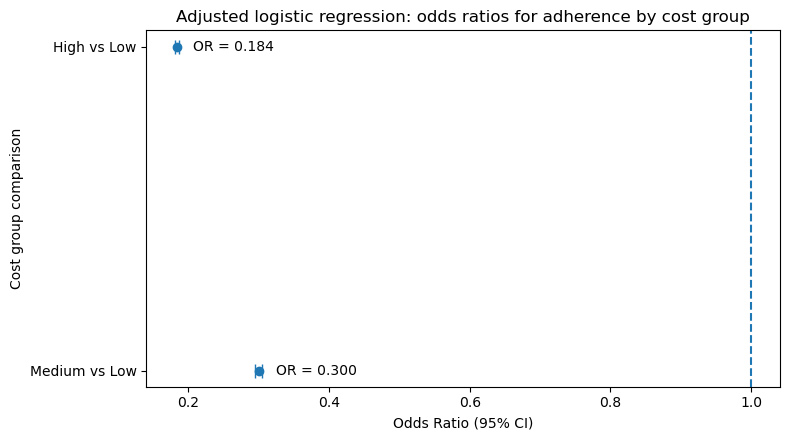

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Extract only the cost-group coefficients from adjusted logistic model
params = logit_model.params
conf = logit_model.conf_int()
pvals = logit_model.pvalues

figure_b_df = pd.DataFrame({
    "Predictor": [
        "Medium vs Low",
        "High vs Low"
    ],
    "coef": [
        params["C(cost_group, Treatment(reference='low'))[T.medium]"],
        params["C(cost_group, Treatment(reference='low'))[T.high]"]
    ],
    "lower_coef": [
        conf.loc["C(cost_group, Treatment(reference='low'))[T.medium]", 0],
        conf.loc["C(cost_group, Treatment(reference='low'))[T.high]", 0]
    ],
    "upper_coef": [
        conf.loc["C(cost_group, Treatment(reference='low'))[T.medium]", 1],
        conf.loc["C(cost_group, Treatment(reference='low'))[T.high]", 1]
    ],
    "p_value": [
        pvals["C(cost_group, Treatment(reference='low'))[T.medium]"],
        pvals["C(cost_group, Treatment(reference='low'))[T.high]"]
    ]
})

# Convert coefficients to odds ratios
figure_b_df["odds_ratio"] = np.exp(figure_b_df["coef"])
figure_b_df["lower_or"] = np.exp(figure_b_df["lower_coef"])
figure_b_df["upper_or"] = np.exp(figure_b_df["upper_coef"])

print(figure_b_df)

# Plot
fig, ax = plt.subplots(figsize=(8, 4.5))

y_pos = np.arange(len(figure_b_df))

ax.errorbar(
    figure_b_df["odds_ratio"],
    y_pos,
    xerr=[
        figure_b_df["odds_ratio"] - figure_b_df["lower_or"],
        figure_b_df["upper_or"] - figure_b_df["odds_ratio"]
    ],
    fmt='o',
    capsize=5
)

ax.axvline(x=1, linestyle='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(figure_b_df["Predictor"])
ax.set_xlabel("Odds Ratio (95% CI)")
ax.set_ylabel("Cost group comparison")
ax.set_title("Adjusted logistic regression: odds ratios for adherence by cost group")

# Add text labels
for i, row in figure_b_df.iterrows():
    ax.text(row["upper_or"] + 0.02, i, f'OR = {row["odds_ratio"]:.3f}', va='center')

plt.tight_layout()
plt.show()
#ax.set_xlim(0.1, 0.4)

GEE Model

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# Keep only variables needed for GEE
gee_data = df_long[[
    "record_id",
    "adherent",
    "cost_group",
    "age_group",
    "gender",
    "survey_week"
]].dropna().copy()

# Make categories explicit
gee_data["cost_group"] = pd.Categorical(
    gee_data["cost_group"],
    categories=["low", "medium", "high"],
    ordered=True
)
gee_data["gender"] = gee_data["gender"].astype("category")
gee_data["survey_week"] = gee_data["survey_week"].astype("category")

# Fit GEE logistic model
gee_model = smf.gee(
    formula="adherent ~ C(cost_group, Treatment(reference='low')) + age_group + C(gender) + C(survey_week)",
    groups="record_id",
    data=gee_data,
    family=sm.families.Binomial(),
    cov_struct=sm.cov_struct.Exchangeable()
).fit()

# Print summary
print(gee_model.summary())

# Odds ratios
gee_odds = pd.DataFrame({
    "Variable": gee_model.params.index,
    "Coefficient": gee_model.params.values,
    "Odds Ratio": np.exp(gee_model.params.values),
    "P-value": gee_model.pvalues.values
})

print("\nGEE ODDS RATIOS:")
print(gee_odds)

                               GEE Regression Results                              
Dep. Variable:                    adherent   No. Observations:               753662
Model:                                 GEE   No. clusters:                    53833
Method:                        Generalized   Min. cluster size:                  14
                      Estimating Equations   Max. cluster size:                  14
Family:                           Binomial   Mean cluster size:                14.0
Dependence structure:         Exchangeable   Num. iterations:                    18
Date:                     Sun, 26 Apr 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         10:00:39
                                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------
Inte

In [ ]:
# Compare cost-group effects: Adjusted Logistic vs GEE
compare_final = pd.DataFrame({
    "Model": ["Adjusted Logistic", "Adjusted Logistic", "GEE", "GEE"],
    "Predictor": ["Medium vs Low", "High vs Low", "Medium vs Low", "High vs Low"],
    "Coefficient": [
        logit_model.params["C(cost_group, Treatment(reference='low'))[T.medium]"],
        logit_model.params["C(cost_group, Treatment(reference='low'))[T.high]"],
        gee_model.params["C(cost_group, Treatment(reference='low'))[T.medium]"],
        gee_model.params["C(cost_group, Treatment(reference='low'))[T.high]"]
    ],
    "Odds Ratio": [
        np.exp(logit_model.params["C(cost_group, Treatment(reference='low'))[T.medium]"]),
        np.exp(logit_model.params["C(cost_group, Treatment(reference='low'))[T.high]"]),
        np.exp(gee_model.params["C(cost_group, Treatment(reference='low'))[T.medium]"]),
        np.exp(gee_model.params["C(cost_group, Treatment(reference='low'))[T.high]"])
    ],
    "P-value": [
        logit_model.pvalues["C(cost_group, Treatment(reference='low'))[T.medium]"],
        logit_model.pvalues["C(cost_group, Treatment(reference='low'))[T.high]"],
        gee_model.pvalues["C(cost_group, Treatment(reference='low'))[T.medium]"],
        gee_model.pvalues["C(cost_group, Treatment(reference='low'))[T.high]"]
    ]
})

print(compare_final.round(4))

               Model      Predictor  Coefficient  Odds Ratio  P-value
0  Adjusted Logistic  Medium vs Low      -1.2040      0.3000      0.0
1  Adjusted Logistic    High vs Low      -1.6914      0.1843      0.0
2                GEE  Medium vs Low      -1.2216      0.2948      0.0
3                GEE    High vs Low      -1.7159      0.1798      0.0


               Model      Predictor      coef  lower_coef  upper_coef  \
0  Adjusted Logistic  Medium vs Low -1.204027   -1.220387   -1.187668   
1  Adjusted Logistic    High vs Low -1.691354   -1.707253   -1.675454   
2                GEE  Medium vs Low -1.221597   -1.239550   -1.203644   
3                GEE    High vs Low -1.715882   -1.735882   -1.695882   

   odds_ratio  lower_or  upper_or  
0    0.299984  0.295116  0.304932  
1    0.184270  0.181363  0.187223  
2    0.294759  0.289515  0.300099  
3    0.179805  0.176245  0.183437  


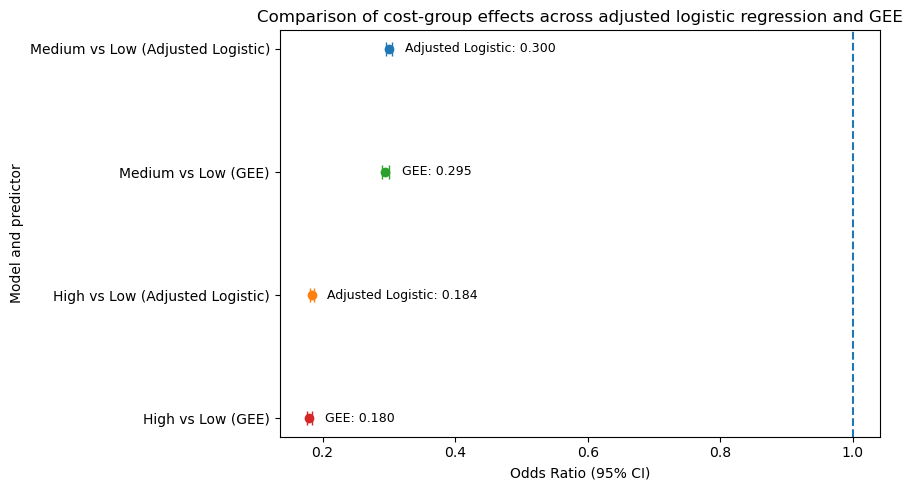

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Adjusted logistic model confidence intervals
logit_conf = logit_model.conf_int()
logit_params = logit_model.params

# GEE model confidence intervals
gee_conf = gee_model.conf_int()
gee_params = gee_model.params

figure_c_df = pd.DataFrame({
    "Model": [
        "Adjusted Logistic", "Adjusted Logistic",
        "GEE", "GEE"
    ],
    "Predictor": [
        "Medium vs Low", "High vs Low",
        "Medium vs Low", "High vs Low"
    ],
    "coef": [
        logit_params["C(cost_group, Treatment(reference='low'))[T.medium]"],
        logit_params["C(cost_group, Treatment(reference='low'))[T.high]"],
        gee_params["C(cost_group, Treatment(reference='low'))[T.medium]"],
        gee_params["C(cost_group, Treatment(reference='low'))[T.high]"]
    ],
    "lower_coef": [
        logit_conf.loc["C(cost_group, Treatment(reference='low'))[T.medium]", 0],
        logit_conf.loc["C(cost_group, Treatment(reference='low'))[T.high]", 0],
        gee_conf.loc["C(cost_group, Treatment(reference='low'))[T.medium]", 0],
        gee_conf.loc["C(cost_group, Treatment(reference='low'))[T.high]", 0]
    ],
    "upper_coef": [
        logit_conf.loc["C(cost_group, Treatment(reference='low'))[T.medium]", 1],
        logit_conf.loc["C(cost_group, Treatment(reference='low'))[T.high]", 1],
        gee_conf.loc["C(cost_group, Treatment(reference='low'))[T.medium]", 1],
        gee_conf.loc["C(cost_group, Treatment(reference='low'))[T.high]", 1]
    ]
})

# Convert to odds ratios
figure_c_df["odds_ratio"] = np.exp(figure_c_df["coef"])
figure_c_df["lower_or"] = np.exp(figure_c_df["lower_coef"])
figure_c_df["upper_or"] = np.exp(figure_c_df["upper_coef"])

print(figure_c_df)

# Plot positions
fig, ax = plt.subplots(figsize=(9, 5))

positions = {
    ("Medium vs Low", "Adjusted Logistic"): 3,
    ("Medium vs Low", "GEE"): 2,
    ("High vs Low", "Adjusted Logistic"): 1,
    ("High vs Low", "GEE"): 0
}

for _, row in figure_c_df.iterrows():
    y = positions[(row["Predictor"], row["Model"])]
    ax.errorbar(
        row["odds_ratio"],
        y,
        xerr=[[row["odds_ratio"] - row["lower_or"]], [row["upper_or"] - row["odds_ratio"]]],
        fmt='o',
        capsize=5
    )
    ax.text(row["upper_or"] + 0.02, y, f'{row["Model"]}: {row["odds_ratio"]:.3f}', va='center', fontsize=9)

ax.axvline(x=1, linestyle='--')
ax.set_yticks([3, 2, 1, 0])
ax.set_yticklabels([
    "Medium vs Low (Adjusted Logistic)",
    "Medium vs Low (GEE)",
    "High vs Low (Adjusted Logistic)",
    "High vs Low (GEE)"
])
ax.set_xlabel("Odds Ratio (95% CI)")
ax.set_ylabel("Model and predictor")
ax.set_title("Comparison of cost-group effects across adjusted logistic regression and GEE")

plt.tight_layout()
plt.show()